In [1]:
import os
Root = "D:/speechemotionrecognization/speechemotion_dataset"
os.chdir(Root)

In [2]:
ls

 Volume in drive D is DATA
 Volume Serial Number is 4CA2-079B

 Directory of D:\speechemotionrecognization\speechemotion_dataset

05/12/2024  15:36    <DIR>          .
06/12/2024  12:55    <DIR>          ..
05/12/2024  15:36    <DIR>          Actor_01
05/12/2024  15:36    <DIR>          Actor_02
05/12/2024  15:36    <DIR>          Actor_03
05/12/2024  15:36    <DIR>          Actor_04
05/12/2024  15:36    <DIR>          Actor_05
05/12/2024  15:36    <DIR>          Actor_06
05/12/2024  15:36    <DIR>          Actor_07
05/12/2024  15:36    <DIR>          Actor_08
05/12/2024  15:36    <DIR>          Actor_09
05/12/2024  15:36    <DIR>          Actor_10
05/12/2024  15:36    <DIR>          Actor_11
05/12/2024  15:36    <DIR>          Actor_12
05/12/2024  15:36    <DIR>          Actor_13
05/12/2024  15:36    <DIR>          Actor_14
05/12/2024  15:36    <DIR>          Actor_15
05/12/2024  15:36    <DIR>          Actor_16
05/12/2024  15:36    <DIR>          Actor_17
05/12/2024  15:36    <DIR>  

In [3]:
import librosa
import soundfile
import os, glob, pickle
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas

In [4]:
len(glob.glob('*'))

23

In [5]:
def extract_feature(file_name, mfcc, chroma, mel):
    with soundfile.SoundFile(file_name) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate=sound_file.samplerate
        if chroma:
            stft=np.abs(librosa.stft(X))
        result=np.array([])
        if mfcc:
            mfccs=np.mean(librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T, axis=0)
            result=np.hstack((result, mfccs))
        if chroma:
            chroma=np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T,axis=0)
            result=np.hstack((result, chroma))
        if mel:
            mel=np.mean(librosa.feature.melspectrogram(y=X, sr=sample_rate).T,axis=0)
            result=np.hstack((result, mel))
    return result

In [6]:

# Emotions in the RAVDESS dataset
emotions={
  '01':'neutral',
  '02':'calm',
  '03':'happy',
  '04':'sad',
  '05':'angry',
  '06':'fearful',
  '07':'disgust',
  '08':'surprised'
}

#Emotions to observe
observed_emotions=['calm', 'happy', 'fearful', 'disgust']



In [7]:
print(observed_emotions)
print(emotions)

['calm', 'happy', 'fearful', 'disgust']
{'01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad', '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'}


In [8]:
#Load the data and extract features for each sound file
def load_data(test_size=0.2):
    x,y=[],[]
    for file in glob.glob("D:/speechemotionrecognization/speechemotion_dataset/Actor_*/*.wav"):
        file_name=os.path.basename(file)
        emotion=emotions[file_name.split("-")[2]]
        if emotion not in observed_emotions:
            continue
        feature=extract_feature(file, mfcc=True, chroma=True, mel=True)
        x.append(feature)
        y.append(emotion)
    return train_test_split(np.array(x), y, test_size=test_size, random_state=9)

In [9]:
len(glob.glob('D:/speechemotionrecognization/speechemotion_dataset/Actor_*/*.wav'))

1260

In [10]:
#Split the dataset
x_train,x_test,y_train,y_test=load_data(test_size=0.25)

In [11]:
x_train

array([[-5.56651917e+02,  4.06022797e+01, -1.17903793e+00, ...,
         2.66004063e-04,  1.58652692e-04,  5.87950526e-05],
       [-4.86668427e+02,  5.08861084e+01, -1.27242441e+01, ...,
         2.52229674e-03,  9.71179106e-04,  4.21704899e-04],
       [-6.27105347e+02,  4.73129539e+01, -5.35420227e+00, ...,
         8.04970750e-06,  6.64392519e-06,  4.04981574e-06],
       ...,
       [-5.50096191e+02,  1.70297680e+01, -1.14575634e+01, ...,
         1.51764631e-04,  1.16828531e-04,  8.47479314e-05],
       [-5.55357605e+02,  4.71569710e+01,  1.10750742e+01, ...,
         1.61086471e-04,  1.04962470e-04,  6.52811723e-05],
       [-5.04816345e+02,  3.53618660e+01, -1.43495779e+01, ...,
         6.08151546e-04,  5.55269653e-04,  4.47782222e-04]])

In [12]:
print(x_train)

[[-5.56651917e+02  4.06022797e+01 -1.17903793e+00 ...  2.66004063e-04
   1.58652692e-04  5.87950526e-05]
 [-4.86668427e+02  5.08861084e+01 -1.27242441e+01 ...  2.52229674e-03
   9.71179106e-04  4.21704899e-04]
 [-6.27105347e+02  4.73129539e+01 -5.35420227e+00 ...  8.04970750e-06
   6.64392519e-06  4.04981574e-06]
 ...
 [-5.50096191e+02  1.70297680e+01 -1.14575634e+01 ...  1.51764631e-04
   1.16828531e-04  8.47479314e-05]
 [-5.55357605e+02  4.71569710e+01  1.10750742e+01 ...  1.61086471e-04
   1.04962470e-04  6.52811723e-05]
 [-5.04816345e+02  3.53618660e+01 -1.43495779e+01 ...  6.08151546e-04
   5.55269653e-04  4.47782222e-04]]


In [206]:
#Get the shape of the training and testing datasets
print((x_train.shape[0], x_test.shape[0]))

(504, 168)


In [14]:
#Get the number of features extracted
print(f'Features extracted: {x_train.shape[1]}')

Features extracted: 180


In [16]:
#Initialize the Multi Layer Perceptron Classifier
model=MLPClassifier(alpha=0.01, batch_size=256, epsilon=1e-08, hidden_layer_sizes=(300,), learning_rate='adaptive', max_iter=500)


In [17]:
#Train the model
model.fit(x_train,y_train)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=0.01, batch_size=256, hidden_layer_sizes=(300,),
              learning_rate='adaptive', max_iter=500)

In [18]:
#Predict for the test set
y_pred=model.predict(x_test)

In [19]:
y_pred

array(['happy', 'disgust', 'happy', 'calm', 'fearful', 'calm', 'disgust',
       'disgust', 'disgust', 'disgust', 'happy', 'fearful', 'disgust',
       'fearful', 'calm', 'calm', 'happy', 'disgust', 'calm', 'calm',
       'fearful', 'happy', 'happy', 'happy', 'calm', 'calm', 'disgust',
       'fearful', 'disgust', 'happy', 'disgust', 'disgust', 'disgust',
       'disgust', 'fearful', 'happy', 'fearful', 'disgust', 'disgust',
       'happy', 'disgust', 'disgust', 'fearful', 'disgust', 'fearful',
       'calm', 'calm', 'happy', 'fearful', 'calm', 'disgust', 'calm',
       'disgust', 'fearful', 'happy', 'disgust', 'calm', 'happy', 'happy',
       'happy', 'disgust', 'calm', 'happy', 'fearful', 'fearful', 'happy',
       'happy', 'fearful', 'calm', 'fearful', 'happy', 'fearful', 'happy',
       'fearful', 'disgust', 'disgust', 'happy', 'fearful', 'calm',
       'fearful', 'happy', 'calm', 'happy', 'calm', 'calm', 'fearful',
       'disgust', 'calm', 'fearful', 'fearful', 'disgust', 'calm',

In [20]:
import pandas as pd
import numpy as np
import hvplot.pandas

# Assuming y_pred is a NumPy array
y_pred = np.array(['neutral','calm','happy','sad','angry','fearful','disgust','surprised'])

# Convert to Pandas Series
y_pred_series = pd.Series(y_pred)

# Count the occurrences of each emotion
emotion_counts = y_pred_series.value_counts()

In [21]:
emotion_counts.hvplot.bar(
    title="Emotion Count", xlabel='Speech emotion', ylabel='Count', 
    width=500, height=350
)

:Bars   [index]   (count)

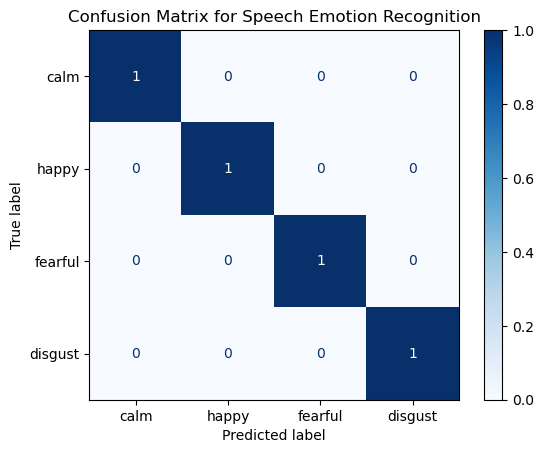

In [22]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# True and predicted labels
y_true = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']
y_pred = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

# Define all possible classes
classes = ['calm', 'happy', 'fearful', 'disgust']

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# Display confusion matrix with specified labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)

# Add title
plt.title("Confusion Matrix for Speech Emotion Recognition")
plt.show()

In [23]:
print("Length of y_true:", len(y_true))
print("Length of y_pred:", len(y_pred))

Length of y_true: 8
Length of y_pred: 8


In [24]:
y_pred=model.predict(x_test) # Ensure X_test is aligned with y_true

In [25]:
y_true = y_true[:len(y_pred)]

In [26]:
print("Unique values in y_true:", np.unique(y_true))
print("Unique values in y_pred:", np.unique(y_pred))

Unique values in y_true: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Unique values in y_pred: ['calm' 'disgust' 'fearful' 'happy']


In [27]:
classes = np.unique(y_true)  # or np.unique(y_pred) if they are the same

Unique values in y_true: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Unique values in y_pred: ['calm' 'disgust' 'fearful' 'happy']


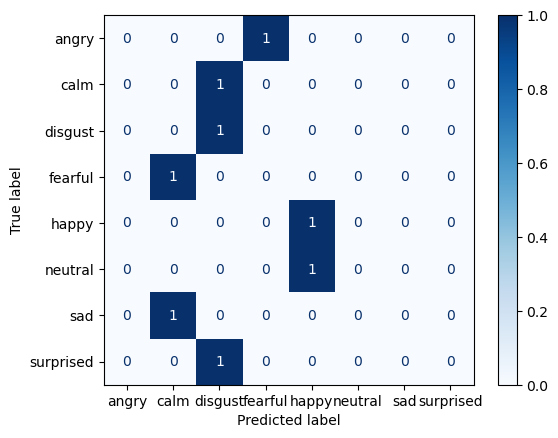

In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Check unique values in y_true and y_pred
print("Unique values in y_true:", np.unique(y_true))
print("Unique values in y_pred:", np.unique(y_pred))

# Align y_true and y_pred lengths if necessary
min_len = min(len(y_true), len(y_pred))
y_true = y_true[:min_len]
y_pred = y_pred[:min_len]

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Update classes if necessary (match the unique values in y_true or y_pred)
classes = np.unique(y_true)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [29]:
from sklearn.metrics import accuracy_score, f1_score

In [30]:
y_pred = model.predict(x_test)
print("Predictions shape:", y_pred.shape)

Predictions shape: (168,)


In [31]:
min_len = min(len(y_test), len(y_pred))
y_test = y_test[:min_len]
y_pred = y_pred[:min_len]
y_pred = y_pred.flatten()

In [32]:
from sklearn.metrics import accuracy_score,f1_score

# Check if lengths of y_test and y_pred match
print("Length of y_test:", len(y_test))
print("Length of y_pred:", len(y_pred))

# If the lengths match, calculate accuracy
if len(y_test) == len(y_pred):
    accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
else:
    print("Mismatch in the number of samples between y_test and y_pred.")

Length of y_test: 168
Length of y_pred: 168
Accuracy: 78.57%


In [33]:
#calculate the accuracy of our model
accuracy=accuracy_score(y_true=y_test, y_pred=y_pred)

#Print the accuracy
print("Accuracy: {:.2f}%".format(accuracy*100))

Accuracy: 78.57%


In [34]:
import pandas as pd
df=pd.DataFrame({'Actual': y_test, 'Predicted':y_pred})
df.head(20)

,Actual,Predicted
0,happy,happy
1,disgust,disgust
2,disgust,happy
3,calm,calm
4,fearful,fearful
5,disgust,calm
6,disgust,disgust
7,disgust,disgust
8,disgust,disgust
9,disgust,disgust


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Actual     168 non-null    object
 1   Predicted  168 non-null    object
dtypes: object(2)
memory usage: 2.8+ KB


In [37]:
df.shape

(168, 2)

In [38]:
df.isnull().sum()

Actual       0
Predicted    0
dtype: int64

In [39]:
df.describe()

,Actual,Predicted
count,168,168
unique,4,4
top,disgust,disgust
freq,52,51


In [40]:
df.Actual.value_counts().hvplot.bar(
    title="Emotion Count", xlabel='Speech emotion', ylabel='Count', 
    width=500, height=350
)


:Bars   [Actual]   (count)

In [41]:
df.Predicted .value_counts().hvplot.bar(
    title="Emotion Count", xlabel='Speech emotion', ylabel='Count', 
    width=500, height=350
)

:Bars   [Predicted]   (count)

In [42]:
categorical_val = []
continous_val = []
for column in df.columns:
    if len(df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

In [43]:
categorical_val

['Actual', 'Predicted']

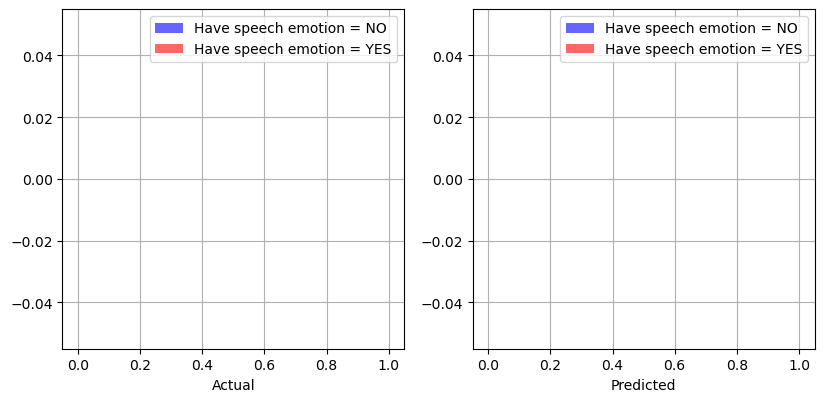

In [44]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(categorical_val, 1):
    plt.subplot(3, 3, i)
    df[df["Predicted"] == 0][column].hist(bins=35, color='blue', label='Have speech emotion = NO', alpha=0.6)
    df[df["Predicted"] == 1][column].hist(bins=35, color='red', label='Have speech emotion = YES', alpha=0.6)
    plt.legend()
    plt.xlabel(column)

In [46]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(continous_val, 1):
    plt.subplot(3, 2, i)
    df[df["Predicted"] == 0][column].hist(bins=35, color='blue', label='Have Heart Disease = NO', alpha=0.6)
    df[df["Predicted"] == 1][column].hist(bins=35, color='red', label='Have Heart Disease = YES', alpha=0.6)
    plt.legend()
    plt.xlabel(column)

<Figure size 1500x1500 with 0 Axes>

In [48]:
import pickle
# Writing different model files to file
with open( 'modelForPrediction1.sav', 'wb') as f:
    pickle.dump(model,f)

In [50]:
filename = 'modelForPrediction1.sav'
loaded_model = pickle.load(open(filename, 'rb')) # loading the model file from the storage

feature=extract_feature("D:/speechemotionrecognization/speechemotion_dataset/Actor_01/03-01-01-01-01-01-01.wav", mfcc=True, chroma=True, mel=True)

feature=feature.reshape(1,-1)

prediction=loaded_model.predict(feature)

In [51]:
feature

array([[-6.93497009e+02,  5.00643921e+01,  5.71450531e-01,
         1.43299656e+01,  3.33636999e+00, -2.54071951e+00,
        -4.05790901e+00, -1.07119989e+01, -7.29413891e+00,
         1.74018884e+00, -4.19064283e+00,  1.95466173e+00,
        -5.24789381e+00,  2.78142977e+00, -3.16756725e+00,
        -3.40008307e+00, -2.37803221e+00, -5.68717599e-01,
        -6.47753334e+00, -1.24320555e+00, -2.80542517e+00,
        -5.43635845e+00, -4.46875274e-01, -3.63516617e+00,
        -2.98372602e+00, -5.63902557e-01, -1.65101945e+00,
        -5.55944800e-01, -3.41018438e+00, -2.24465466e+00,
        -3.13058877e+00, -2.70089960e+00, -1.88821328e+00,
        -5.54154336e-01, -3.96459866e+00, -2.13485217e+00,
        -3.94577050e+00, -1.62457860e+00, -2.03990722e+00,
        -3.62910843e+00,  6.33734703e-01,  6.48760676e-01,
         6.21744215e-01,  6.34553254e-01,  6.60345674e-01,
         6.60463989e-01,  7.00949013e-01,  7.31556237e-01,
         7.46921539e-01,  7.23420501e-01,  7.16119528e-0